# Clinical trial analysis: survival curves and hazard ratios

Many medical questions are about *time*: how long until a disease
progresses, a patient is readmitted, or a device fails. The same tools work
for business questions too: how long until a customer churns or a machine
breaks.

Time-to-event data has one twist that breaks ordinary statistics:
**censoring**. When a trial ends, some patients haven't progressed yet. We
know they lasted *at least* that long, but not how long they would have
lasted. Throwing them away, or treating them as if they never progressed,
both give wrong answers.

This notebook analyses a simulated two-arm trial:

1. Checking randomisation worked
2. Why naive comparisons mislead
3. Kaplan-Meier survival curves
4. The log-rank test
5. Cox regression and the hazard ratio

Because the data is simulated, we know the truth: the treatment cuts the
risk of progression by 30% (a hazard ratio of 0.70).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.duration.hazard_regression import PHReg
from statsmodels.duration.survfunc import SurvfuncRight, survdiff

from sample_data import clinical_trial

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})
trial = clinical_trial()
print(f"{len(trial)} patients; follow-up up to {trial.months.max():.0f} months")
trial.head()

800 patients; follow-up up to 36 months


,patient_id,arm,age,stage,months,progressed
0,1,treatment,47,3,32.93,1
1,2,treatment,59,3,1.09,1
2,3,treatment,58,2,32.69,1
3,4,treatment,74,2,36.00,0
4,5,control,66,2,3.83,1


Each row is one patient: which arm they were randomised to, their age and
cancer stage, how many months they were followed, and whether the disease
progressed in that time (`progressed = 0` means censored: still fine when
we last saw them).

## 1. Did randomisation work?

Randomising patients to arms is what lets us credit any difference to the
treatment. Still, check the arms look alike at the start. If they don't, by
bad luck or a broken process, adjust for the imbalance in the analysis.

In [ ]:
baseline = trial.groupby("arm").agg(patients=("patient_id", "size"), median_age=("age", "median"),
                                    stage_3_share=("stage", lambda s: (s == 3).mean()))
print(baseline.to_string(formatters={"stage_3_share": "{:.0%}".format}))

           patients  median_age stage_3_share
arm                                          
control         406        62.0           40%
treatment       394        62.0           41%


Similar size, age and stage mix. Good.

## 2. Why the obvious comparisons mislead

In [ ]:
progressed = trial[trial.progressed == 1]
naive = pd.DataFrame({
    "progressed_share": trial.groupby("arm").progressed.mean(),
    "mean_months_if_progressed": progressed.groupby("arm").months.mean(),
    "censored": (trial.progressed == 0).groupby(trial.arm).sum(),
})
print(naive.round(2).to_string())

           progressed_share  mean_months_if_progressed  censored
arm                                                             
control                0.67                      11.93       134
treatment              0.59                      12.47       160


Both numbers are flawed:

- **Share who progressed** ignores *when*. A drug that delays progression
  from 6 months to 30 months could show the same share by the end.
- **Average time among those who progressed** throws away every censored
  patient. Those are disproportionately the ones doing well, so it's biased.
  If a treatment works, it pushes events later, which can even make its
  "average time to progression" look no better.

We need methods that use every patient for as long as we observed them.

## 3. Kaplan-Meier curves

The Kaplan-Meier estimate walks forward in time. At each event it asks: of
the patients still being followed at this moment, what share progressed?
Censored patients count while we can see them, then quietly leave the
denominator. Multiplying those step-by-step survival shares gives the curve.

control    median time to progression: 17.1 months; progression-free at 24 months: 38%
treatment  median time to progression: 18.8 months; progression-free at 24 months: 46%


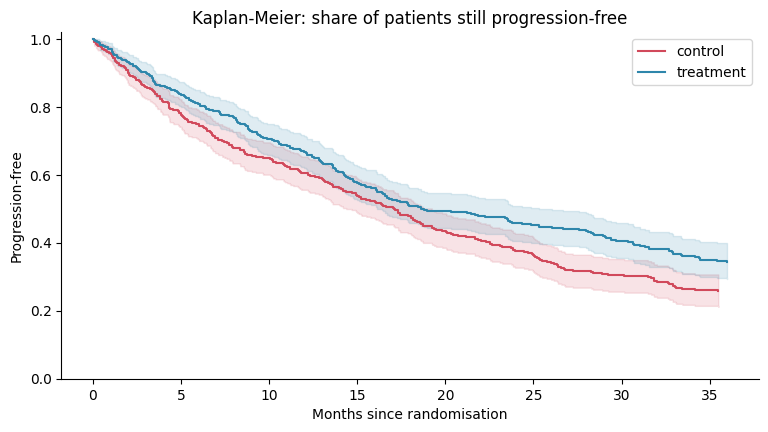

In [ ]:
fig, ax = plt.subplots()
medians = {}
for arm, color in [("control", "#d1495b"), ("treatment", "#2e86ab")]:
    group = trial[trial.arm == arm]
    sf = SurvfuncRight(group.months, group.progressed)
    ax.step(np.r_[0, sf.surv_times], np.r_[1, sf.surv_prob], where="post", color=color, label=arm)
    ci_low = np.clip(sf.surv_prob - 1.96 * sf.surv_prob_se, 0, 1)  # pointwise 95% interval
    ci_high = np.clip(sf.surv_prob + 1.96 * sf.surv_prob_se, 0, 1)
    ax.fill_between(np.r_[0, sf.surv_times], np.r_[1, ci_low], np.r_[1, ci_high], step="post",
                    color=color, alpha=0.15)
    medians[arm] = sf.quantile(0.5)
    at_24 = sf.surv_prob[sf.surv_times <= 24][-1]
    print(f"{arm:<10} median time to progression: {medians[arm]:.1f} months; "
          f"progression-free at 24 months: {at_24:.0%}")
ax.set(title="Kaplan-Meier: share of patients still progression-free", xlabel="Months since randomisation",
       ylabel="Progression-free", ylim=(0, 1.02))
ax.legend();

The treatment curve stays above the control curve throughout, and the gap
grows with time: the medians differ by under two months, but by two years
noticeably more treated patients are still progression-free. That's why a
single summary like the median can undersell a treatment; look at the whole
curve. The shaded bands show uncertainty, and widen as fewer patients
remain under follow-up.

## 4. Is the difference real? The log-rank test

The log-rank test compares the two curves over their whole length. At each
event time it compares how many progressions each arm had against what we'd
expect if the treatment did nothing.

In [ ]:
chi2, p_value = survdiff(trial.months, trial.progressed, trial.arm)
print(f"Log-rank test: chi-square {chi2:.1f}, p-value {p_value:.4f}")

Log-rank test: chi-square 6.8, p-value 0.0091


A small p-value: a gap this large would be very unlikely if the treatment had
no effect.

## 5. Cox regression: how big is the effect?

The **Cox proportional hazards model** estimates how each factor changes the
*hazard*, the instantaneous risk of progressing at any moment, given you
haven't yet. Its output is a **hazard ratio**:

- 1.0 means no effect
- 0.70 means 30% lower risk at every point in time
- 1.5 means 50% higher risk

Including age and stage alongside treatment adjusts for them, and makes
the treatment estimate more precise.

In [ ]:
design = pd.DataFrame({"treatment": (trial.arm == "treatment").astype(int),
                       "age_per_10_years": (trial.age - 62) / 10,
                       "stage_3": (trial.stage == 3).astype(int)})
cox = PHReg(trial.months, design, status=trial.progressed).fit()

results = pd.DataFrame({"hazard_ratio": np.exp(cox.params), "ci_low": np.exp(cox.conf_int()[:, 0]),
                        "ci_high": np.exp(cox.conf_int()[:, 1]), "p_value": cox.pvalues}, index=design.columns)
results["true_value"] = [0.70, np.exp(0.3), np.exp(0.5)]  # what we built into the simulation
print(results.round(3).to_string())

                  hazard_ratio  ci_low  ci_high  p_value  true_value
treatment                0.788   0.661    0.939    0.008       0.700
age_per_10_years         1.352   1.238    1.476    0.000       1.350
stage_3                  1.710   1.436    2.038    0.000       1.649


The estimated treatment hazard ratio is about 0.79, a little weaker than the
true 0.70. That's ordinary sampling noise with 800 patients, and the 95%
interval (about 0.66 to 0.94) contains the truth. It's a useful reminder:
even a correctly run trial gives an estimate, not the exact answer, which is
why the interval matters as much as the headline number. Age and stage come
out almost exactly as built in.

How to say this in plain words: *"Patients on the treatment had about a 20%
lower risk of progression at any given time, after accounting for age and
stage, though the true benefit could plausibly be anywhere from about 6% to
34%."*

The Cox model assumes the hazard ratio is roughly constant over time
("proportional hazards"). Curves that cross, or effects that fade after a
few months, break that assumption, so always look at the Kaplan-Meier plot
before trusting a single hazard ratio.

## Takeaways

- Time-to-event data needs methods that handle censoring; simple averages are biased.
- Kaplan-Meier curves show the whole story; report medians and fixed-time rates from them.
- The log-rank test asks whether the curves differ; Cox regression says by how much.
- A hazard ratio below 1 means lower risk at every moment, not "fewer events in total".
- Check randomisation, and check the proportional hazards assumption visually.
- The same toolkit answers business questions: time to churn, time to first purchase, time to failure.